# Premières architectures de LeCun

In [1]:
import torch
import torch.nn as nn

In [2]:
device  = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
class LeNet1989(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet1989, self).__init__()
        # First conv layer
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5)      # 1x28x28 -> 4x24x24
        self.pool1 = nn.AvgPool2d(2)                     # 4x24x24 -> 4x12x12

        # Second conv layer
        self.conv2 = nn.Conv2d(4, 12, kernel_size=5)     # 4x12x12 -> 12x8x8
        self.pool2 = nn.AvgPool2d(2)                     # 12x8x8 -> 12x4x4

        # Fully connected
        self.fc1   = nn.Linear(12*4*4, 60)
        self.fc2   = nn.Linear(60, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = torch.tanh(self.fc1(x))
        x = self.fc2(x)   # logits
        return x


In [4]:
model = LeNet1989()
model

LeNet1989(
  (conv1): Conv2d(1, 4, kernel_size=(5, 5), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(4, 12, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=192, out_features=60, bias=True)
  (fc2): Linear(in_features=60, out_features=10, bias=True)
)

In [5]:
class LeNet5(nn.Module):  # 1998
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # First conv layer
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)      # 1x28x28 -> 6x24x24
        self.pool1 = nn.AvgPool2d(2)                     # 6x24x24 -> 6x12x12

        # Second conv layer
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)     # 6x12x12 -> 16x8x8
        self.pool2 = nn.AvgPool2d(2)                     # 16x8x8 -> 16x4x4

        # Fully connected
        self.fc1   = nn.Linear(16*4*4, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)   # logits
        return x


In [6]:
model = LeNet5()
model

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

# La convolution

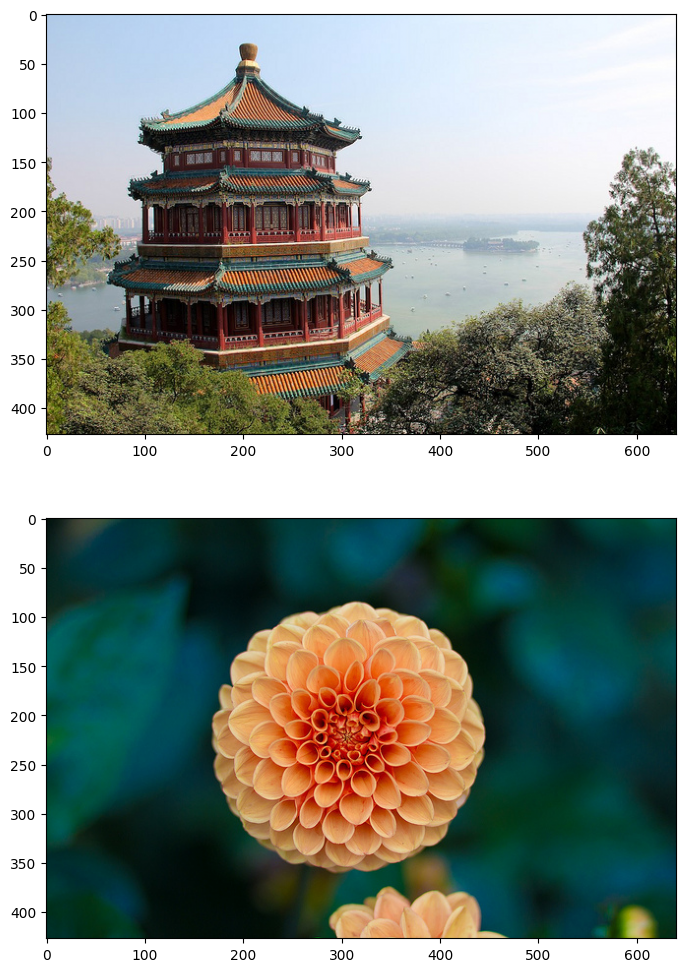

In [7]:
import numpy as np
from sklearn.datasets import load_sample_image
import matplotlib.pyplot as plt

# Load sample images
china = load_sample_image("china.jpg") / 255.
flower = load_sample_image("flower.jpg") / 255.

fig, ax = plt.subplots(2, 1, figsize=(15, 12))
ax[0].imshow(china)
ax[1].imshow(flower)

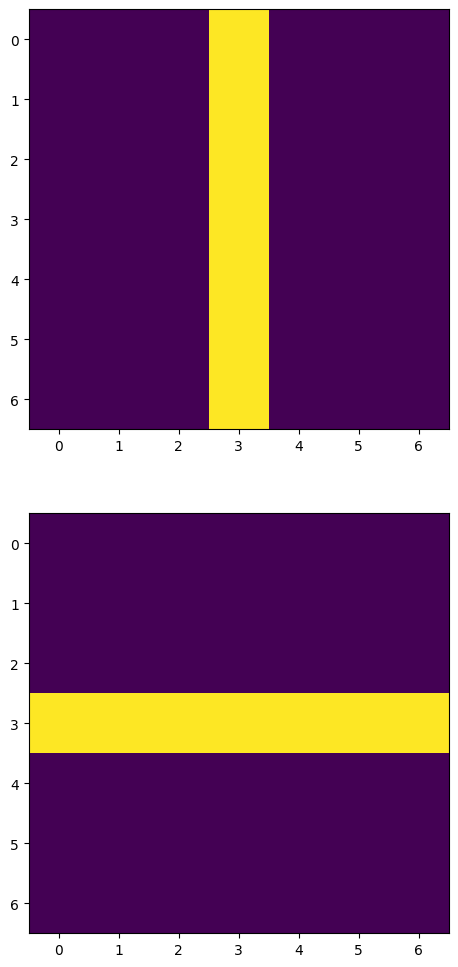

In [8]:
# Create a batch of images
images = np.array([china, flower])
batch_size, height, width, channels = images.shape

# Create 2 filters: one vertical and one horizontal
filters = np.zeros(shape=(2, channels, 7, 7), dtype=np.float32)
filters[0, :, :, 3] = 1  # vertical line
filters[1, :, 3, :] = 1  # horizontal line

fig, ax = plt.subplots(2, 1, figsize=(15, 12))
ax[0].imshow(filters[0, 0, :, :])
ax[1].imshow(filters[1, 0, :, :])

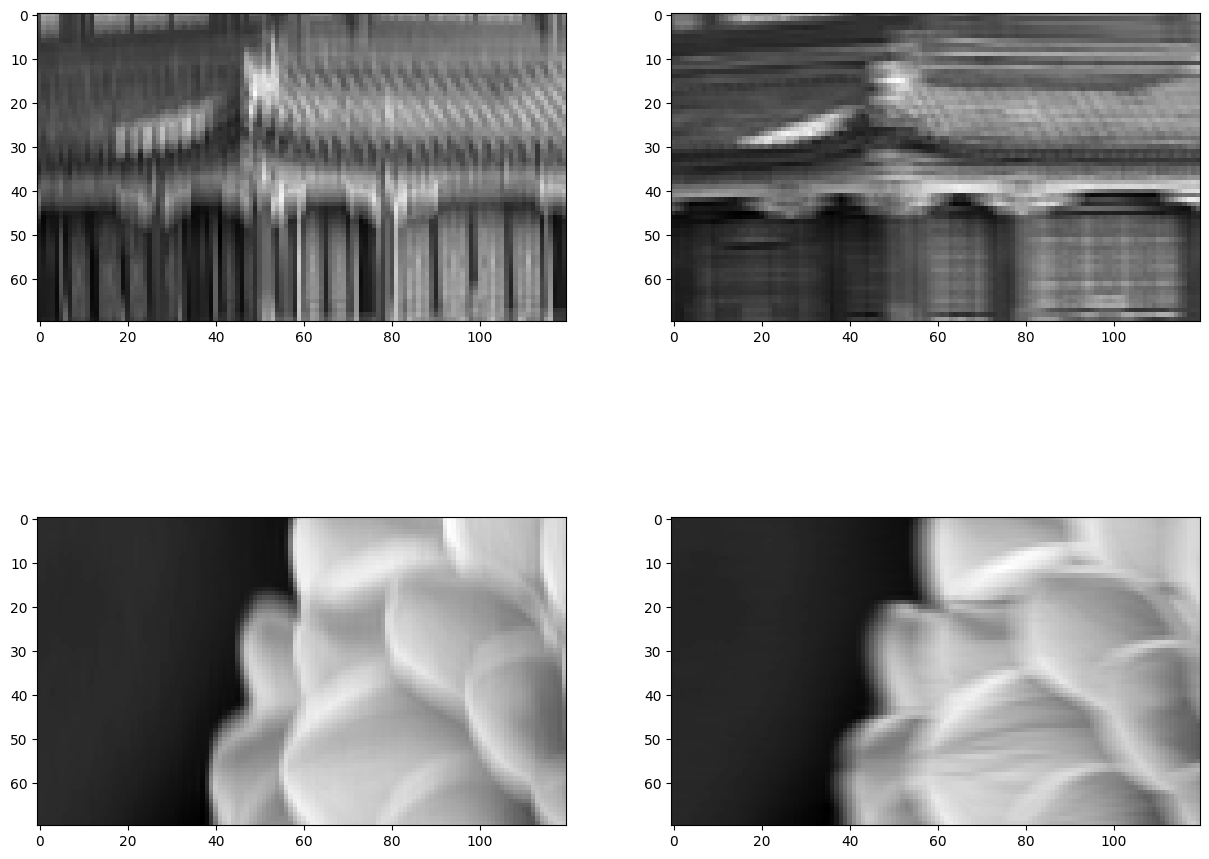

In [9]:
conv_layers = torch.nn.Conv2d(in_channels=3, out_channels=2, kernel_size=7, stride=1, padding="same")
conv_layers.weight = torch.nn.Parameter(torch.tensor(filters))

outputs = conv_layers(torch.tensor(images, dtype=torch.float32).permute([0, 3, 1 ,2])).detach()

def crop(images):
    return images[150:220, 130:250]


fig, ax = plt.subplots(2, 2, figsize=(15, 12))

ax[0, 0].imshow(crop(outputs[0, 0, :, :]), cmap='gray')
ax[0, 1].imshow(crop(outputs[0, 1, :, :]), cmap='gray')

ax[1, 0].imshow(crop(outputs[1, 0, :, :]), cmap='gray')
ax[1, 1].imshow(crop(outputs[1, 1, :, :]), cmap='gray')

# Exercice modification LeNet-5
Modifier afin d'intégrer le GlobalAvgPooling et vérifier les formats de sorties des 2 modèles sur une image au format native et une autre non native

In [10]:
x_natif = torch.randn((1, 1, 28, 28))  # Format natif
x_other = torch.randn((1, 1, 256, 512))  # Format non natif

In [11]:
class LeNet5_GAP(nn.Module): 
    def __init__(self, num_classes=10):
        super(LeNet5_GAP, self).__init__()
        # First conv layer
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)      # 1x28x28 -> 6x24x24
        self.pool1 = nn.AvgPool2d(2)                     # 6x24x24 -> 6x12x12

        # Second conv layer
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)     # 6x12x12 -> 16x8x8
        self.pool2 = nn.AvgPool2d(2)                     # 16x8x8 -> 16x4x4

        # Fully connected
        self.fc1   = nn.Linear(16, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = x.mean(dim=[2, 3])
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)   # logits
        return x


In [12]:
lenet5 = LeNet5(10)
lenet5_gap = LeNet5_GAP(10)

print(lenet5(x_natif).shape)
print(lenet5_gap(x_natif).shape)

torch.Size([1, 10])
torch.Size([1, 10])


In [13]:
print(lenet5_gap(x_other).shape)
print(lenet5(x_other).shape)  #-> erreur

torch.Size([1, 10])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x122000 and 256x120)

# Exercice : Voir architecture MLP utiliser sur MNIST et comparer le nombre de paramètres entre MLP et CNN ainsi que les performances entre les deux

In [14]:
import torchvision

batch_size = 4
trainset = torchvision.datasets.MNIST(root='.', train=True, download=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='.', train=False, download=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

In [15]:
import torch
from torch import nn

class MLP(torch.nn.Module):
    def __init__(self, in_shape, n_neurons, num_hiddens_layers, num_classes):
        super(MLP, self).__init__()
        self.input_layer = nn.Linear(in_shape, n_neurons)
        layers = []
        for _ in range(num_hiddens_layers):
            layers.append(nn.Linear(n_neurons, n_neurons))
            layers.append(nn.ReLU())
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(n_neurons, num_classes, bias=False)

    def forward(self, x):
        i = nn.ReLU()(self.input_layer(x))
        h = self.hidden_layers(i)
        y = nn.Softmax(dim=1)(self.output_layer(h))
        return y


In [16]:
mlp_mnist_classifier = MLP(in_shape=28*28, n_neurons=64, num_hiddens_layers=3, num_classes=10).to(device)
# Assuming mnist_classifier is already defined
total_params = sum(p.numel() for p in mlp_mnist_classifier.parameters())
trainable_params = sum(p.numel() for p in mlp_mnist_classifier.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 63360
Trainable parameters: 63360


In [17]:
mlp_mnist_classifier.hidden_layers

Sequential(
  (0): Linear(in_features=64, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): ReLU()
)

In [18]:
# Optimiseur et loss
learning_rate = 1e-3
optimizer = torch.optim.Adam(mlp_mnist_classifier.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

# Entraînement
n_epochs = 10
for epoch in range(1, n_epochs+1):
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in trainloader:  # Mini-Batch
        # Forward pass
        y_pred = mlp_mnist_classifier(xb.to(device))

        # Loss
        loss = criterion(y_pred, yb.to(device))

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

        # Accuracy
        preds = torch.argmax(y_pred.cpu(), dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = total_loss / total
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch:3d} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\Chakib\Desktop\up_to_date\.venv\Lib\site-packages\torch\utils\data\_utils\worker.py", line 374, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Chakib\Desktop\up_to_date\.venv\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 57, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Chakib\Desktop\up_to_date\.venv\Lib\site-packages\torch\utils\data\_utils\collate.py", line 401, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Chakib\Desktop\up_to_date\.venv\Lib\site-packages\torch\utils\data\_utils\collate.py", line 214, in collate
    return [
           ^
  File "c:\Users\Chakib\Desktop\up_to_date\.venv\Lib\site-packages\

In [ ]:
cnn_mnist_classifier = LeNet5_GAP(num_classes=10).to(device)

# Assuming mnist_classifier is already defined
total_params = sum(p.numel() for p in cnn_mnist_classifier.parameters())
trainable_params = sum(p.numel() for p in cnn_mnist_classifier.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

In [ ]:
from torch.utils.data import Dataset, DataLoader

class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Retourne une paire (image, label)
        return self.X[idx], self.y[idx]
    

# Optimiseur et loss
learning_rate = 1e-3
optimizer = torch.optim.Adam(cnn_mnist_classifier.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

batch_size = 32
dataset = MNISTDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Entraînement
n_epochs = 10
for epoch in range(1, n_epochs+1):
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in dataloader:  # Mini-Batch
        # Forward pass
        y_pred = cnn_mnist_classifier(xb.to(device))

        # Loss
        loss = criterion(y_pred, yb.to(device))

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

        # Accuracy
        preds = torch.argmax(y_pred.cpu(), dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = total_loss / total
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch:3d} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

# Transfer Learning
Comparer un modèle pré-entrainé à un modèle from scratch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import time
import numpy as np

# ===========================
# Hyperparamètres
# ===========================
batch_size = 64
num_classes = 10
num_epochs = 5
learning_rate = 0.001
subset_fraction = 0.1  # 10% du dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===========================
# Dataset & DataLoader
# ===========================
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # data augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# On ne garde qu'une fraction du dataset pour accentuer l'effet transfer learning
subset_size = int(len(train_dataset_full) * subset_fraction)
subset_indices = np.random.choice(len(train_dataset_full), subset_size, replace=False)
train_dataset = Subset(train_dataset_full, subset_indices)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# ===========================
# Fonctions d'entraînement et d'évaluation
# ===========================
def train_model(model, criterion, optimizer, num_epochs):
    model = model.to(device)
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} - Time: {time.time()-start_time:.1f}s")

def evaluate_model(model):
    model.eval()
    model = model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    acc = correct / total
    print(f"Test Accuracy: {acc:.4f}")
    return acc

# ===========================
# 1) Model from scratch
# ===========================
print("=== Training from scratch (10% dataset) ===")
model_scratch = models.mobilenet_v2(pretrained=False)
model_scratch.classifier[1] = nn.Linear(model_scratch.last_channel, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_scratch.parameters(), lr=learning_rate)

train_model(model_scratch, criterion, optimizer, num_epochs)
acc_scratch = evaluate_model(model_scratch)


In [ ]:
# ===========================
# 2) Transfer Learning
# ===========================
print("\n=== Transfer Learning (10% dataset) ===")
model_tl = models.mobilenet_v2(pretrained=True)
for param in model_tl.features.parameters():
    param.requires_grad = False  # gèle les couches convolutives

model_tl.classifier[1] = nn.Linear(model_tl.last_channel, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tl.classifier.parameters(), lr=learning_rate)

train_model(model_tl, criterion, optimizer, num_epochs)
acc_tl = evaluate_model(model_tl)

print(f"\nAccuracy from scratch: {acc_scratch:.4f}")
print(f"Accuracy with transfer learning: {acc_tl:.4f}")

In [ ]:
model_scratch.classifier[1] = nn.Linear(1280, 10)

# Exercice : Autoencodeur de débruitage d'images (FashionMNIST)

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# --- 1. Dataset avec bruit gaussien ---
class NoisyFashionMNIST(Dataset):
    def __init__(self, train=True, noise_std=0.3):
        self.dataset = torchvision.datasets.FashionMNIST(
            root="./data", train=train, download=True, transform=transforms.ToTensor()
        )
        self.noise_std = noise_std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]   # img: [1,28,28], valeurs [0,1]
        noisy_img = img + torch.randn_like(img) * self.noise_std
        noisy_img = torch.clamp(noisy_img, 0., 1.)  # garder dans [0,1]
        return noisy_img, img  # x = bruité, y = original

# --- 2. Dataloader ---
train_dataset = NoisyFashionMNIST(train=True)
test_dataset  = NoisyFashionMNIST(train=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

# --- 3. Autoencodeur convolutionnel simple ---
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14x14 -> 7x7
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            # Voir nn.ConvTranspose2d 7x7 -> 14x14
            nn.ReLU(),
            # Voir nn.ConvTranspose2d 14x14 -> 28x28
            nn.Sigmoid()  # pour rester dans [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

# --- 4. Exemple d'entraînement ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Boucle d'entraînement rapide. Une seule epoch suffit.
count = 0
for epoch in range(1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        count += 1
        if count == 110:  # L'augmenter de 10 en 10 en exécutant la cellule d'après pour voir l'évolution
            break
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}")


In [ ]:
import matplotlib.pyplot as plt
import torch

# Assurer que le modèle est en mode évaluation
model.eval()

# Récupérer un batch de test
x_batch, y_batch = next(iter(test_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)

# Prédiction du modèle
with torch.no_grad():
    y_pred = model(x_batch)

# Visualisation des 6 premières images
n = 6
plt.figure(figsize=(12, 4))
for i in range(n):
    # Image bruitée
    plt.subplot(2, n, i+1)
    plt.imshow(x_batch[i].cpu().squeeze(), cmap='gray')
    plt.title("Bruitée")
    plt.axis('off')
    
    # Image reconstruite
    plt.subplot(2, n, i+1+n)
    plt.imshow(y_pred[i].cpu().squeeze(), cmap='gray')
    plt.title("Reconstruite")
    plt.axis('off')

plt.tight_layout()
plt.show()


# Exercice additionnel : Détection d'anomalie par extraction de caractéristiques

In [ ]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224
BATCH_SIZE = 16

# =====================================================================
# ÉTAPE 1 : Le Dataset MVTec (À compléter)
# =====================================================================
# Rappel de la structure MVTec :
# class_folder/train/good/*.png (Données saines uniquement)
# class_folder/test/anomaly_type/*.png (Données anormales)
# class_folder/test/good/*.png (Données saines de test)

class MVTecDataset(Dataset):
    def __init__(self, root_dir, category, is_train=True, transform=None):
        """
        root_dir: Chemin vers le dossier racine de MVTec (ex: './mvtec')
        category: Nom de la classe (ex: 'bottle', 'cable', etc.)
        is_train: True pour charger le train set (good), False pour le test set
        """
        self.root_dir = root_dir
        self.category = category
        self.is_train = is_train
        self.transform = transform
        
        self.image_paths = []
        self.labels = [] # 0 pour normal, 1 pour anomalie
        
        self._load_dataset()

    def _load_dataset(self):
        if self.is_train:
            # TODO: Lister les images du dossier 'train/good'
            # Les étiqueter à 0
            pass
        else:
            # TODO: Lister toutes les images du dossier 'test' (tous les sous-dossiers)
            # Si le sous-dossier est 'good' -> label 0, sinon -> label 1
            pass

    def __len__(self):
        # TODO: Retourner la taille du dataset
        return 0

    def __getitem__(self, idx):
        # TODO: Charger l'image en RGB, appliquer les transforms
        # Retourner l'image transformée et son label
        pass

# Transformations standards ImageNet
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# =====================================================================
# ÉTAPE 2 : Extracteur de Features (À compléter)
# =====================================================================
class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        # TODO: Charger un modèle ResNet18 pré-entraîné standard de torchvision
        # Pensez à utiliser les arguments récents de l'API (ex: weights=...)
        resnet = None 
        
        # Nous voulons extraire les caractéristiques de couches intermédiaires.
        # On choisit de couper le réseau après la 'layer3' pour garder une résolution spatiale correcte.
        # TODO: Isoler les couches de resnet du début jusqu'à 'layer3' incluse.
        # Indice: list(resnet.children()) permet de découper le modèle.
        self.feature_extractor = None
        
        # TODO: Geler l'intégralité des paramètres (pas de calcul de gradient)
        
        self.eval()

    def forward(self, x):
        # TODO: Passer l'image dans l'extracteur et retourner la feature map
        return None


# =====================================================================
# ÉTAPE 3 : Modélisation de la Normalité (Train) - À compléter
# =====================================================================
def train_distribution(feature_extractor, train_loader):
    """
    Calcule la moyenne et la variance de chaque canal pour chaque position spatiale (h, w)
    sur l'ensemble des données d'entraînement normales.
    """
    feature_extractor.eval()
    all_features = []
    
    with torch.no_grad():
        for images, _ in train_loader:
            images = images.to(DEVICE)
            # TODO: Extraire les features
            features = None 
            all_features.append(features.cpu())
            
    # Concaténation de toutes les features de train shape: [N, C, H, W]
    all_features = torch.cat(all_features, dim=0)
    
    # TODO: Calculer la moyenne empirique (mean) suivant la dimension des images (N)
    # Résultat attendu shape: [C, H, W]
    mean = None
    
    # TODO: Calculer la variance empirique (var) suivant la dimension des images (N)
    # Résultat attendu shape: [C, H, W]
    var = None
    
    return mean, var


# =====================================================================
# ÉTAPE 4 : Inférence et Génération de la Heatmap (À compléter)
# =====================================================================
def predict_anomaly_map(feature_extractor, test_image, mean, var, epsilon=1e-5):
    """
    Calcule la carte d'anomalie pour une image de test.
    test_image: Tensor de shape [1, 3, H_img, W_img]
    mean: Tensor de shape [C, H_feat, W_feat] (Distribution normale)
    var: Tensor de shape [C, H_feat, W_feat] (Distribution normale)
    """
    feature_extractor.eval()
    with torch.no_grad():
        # TODO: Extraire la feature map de l'image de test [1, C, H_feat, W_feat]
        test_feat = None 
    
    # Suppression de la dimension de batch pour s'aligner sur mean et var
    test_feat = test_feat.squeeze(0).cpu() # Shape: [C, H_feat, W_feat]
    
    # TODO: Calculer la distance de Mahalanobis diagonale point par point.
    # Formule mathématique simplifiée pour chaque pixel (h,w) :
    # d = sqrt( sum_over_channels( (test_feat - mean)^2 / (var + epsilon) ) )
    # Indice: Utilisez les opérations vectorielles de PyTorch (.sum(dim=0))
    # Shape attendue après somme: [H_feat, W_feat]
    anomaly_map = None 
    
    # Ajouter la dimension de batch et de canal pour l'interpolation [1, 1, H_feat, W_feat]
    anomaly_map = anomaly_map.unsqueeze(0).unsqueeze(0)
    
    # TODO: Upsampler la carte d'anomalie à la taille d'origine de l'image (IMAGE_SIZE)
    # Indice: Utilisez F.interpolate avec le mode 'bilinear'
    anomaly_map_resized = None
    
    # Extraction du tenseur 2D final
    anomaly_map_resized = anomaly_map_resized.squeeze().numpy()
    
    # TODO: Appliquer un filtre gaussien (smooth) pour lisser les "zones chaudes"
    # Indice: Utilisez la fonction `gaussian_filter` importée de scipy avec un sigma=4
    anomaly_map_smoothed = None
    
    return anomaly_map_smoothed


# =====================================================================
# SCRIPT PRINCIPAL DE VÉRIFICATION (Fourni)
# =====================================================================
if __name__ == "__main__":
    # Remplacer par vos chemins locaux
    DATA_PATH = "./mvtec" 
    CATEGORY = "bottle"
    
    # Initialisation des structures
    train_dataset = MVTecDataset(DATA_PATH, CATEGORY, is_train=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    test_dataset = MVTecDataset(DATA_PATH, CATEGORY, is_train=False, transform=transform)
    
    extractor = FeatureExtractor().to(DEVICE)
    
    print("Étape 3 : Estimation de la distribution normale...")
    mean, var = train_distribution(extractor, train_loader)
    print(f"Distribution calculée. Forme des tenseurs de référence : {mean.shape}")
    
    print("Étape 4 : Inférence sur une image de test...")
    # Prendre une image de test aléatoire
    sample_idx = np.random.randint(0, len(test_dataset))
    img_tensor, label = test_dataset[sample_idx]
    
    # Génération de la heatmap
    heatmap = predict_anomaly_map(extractor, img_tensor.unsqueeze(0).to(DEVICE), mean, var)
    
    # Visualisation
    # Re-transformer le tenseur normalisé en image affichable
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    orig_img = inv_normalize(img_tensor).permute(1, 2, 0).clip(0, 1).numpy()
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Image de test (Label réel: {'Anomalie' if label == 1 else 'Sain'})")
    plt.imshow(orig_img)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Heatmap d'anomalie détectée")
    plt.imshow(orig_img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5) # Superposition de la heatmap
    plt.axis('off')
    plt.show()

# Exercice additionnel : Autoencoder pour la détection d'anomalie

In [ ]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 224
BATCH_SIZE = 16

# =====================================================================
# ÉTAPE 1 : Le Dataset MVTec (À compléter)
# =====================================================================
# Rappel de la structure MVTec :
# class_folder/train/good/*.png (Données saines uniquement)
# class_folder/test/anomaly_type/*.png (Données anormales)
# class_folder/test/good/*.png (Données saines de test)

class MVTecDataset(Dataset):
    def __init__(self, root_dir, category, is_train=True, transform=None):
        """
        root_dir: Chemin vers le dossier racine de MVTec (ex: './mvtec')
        category: Nom de la classe (ex: 'bottle', 'cable', etc.)
        is_train: True pour charger le train set (good), False pour le test set
        """
        self.root_dir = root_dir
        self.category = category
        self.is_train = is_train
        self.transform = transform
        
        self.image_paths = []
        self.labels = [] # 0 pour normal, 1 pour anomalie
        
        self._load_dataset()

    def _load_dataset(self):
        if self.is_train:
            # TODO: Lister les images du dossier 'train/good'
            # Les étiqueter à 0
            pass
        else:
            # TODO: Lister toutes les images du dossier 'test' (tous les sous-dossiers)
            # Si le sous-dossier est 'good' -> label 0, sinon -> label 1
            pass

    def __len__(self):
        # TODO: Retourner la taille du dataset
        return 0

    def __getitem__(self, idx):
        # TODO: Charger l'image en RGB, appliquer les transforms
        # Retourner l'image transformée et son label
        pass

# Transformations standards ImageNet
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# =====================================================================
# ÉTAPE 2 : Extracteur de Features (À compléter)
# =====================================================================
class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        # TODO: Charger un modèle ResNet18 pré-entraîné standard de torchvision
        # Pensez à utiliser les arguments récents de l'API (ex: weights=...)
        resnet = None 
        
        # Nous voulons extraire les caractéristiques de couches intermédiaires.
        # On choisit de couper le réseau après la 'layer3' pour garder une résolution spatiale correcte.
        # TODO: Isoler les couches de resnet du début jusqu'à 'layer3' incluse.
        # Indice: list(resnet.children()) permet de découper le modèle.
        self.feature_extractor = None
        
        # TODO: Geler l'intégralité des paramètres (pas de calcul de gradient)
        
        self.eval()

    def forward(self, x):
        # TODO: Passer l'image dans l'extracteur et retourner la feature map
        return None


# =====================================================================
# ÉTAPE 3 : Modélisation de la Normalité (Train) - À compléter
# =====================================================================
def train_distribution(feature_extractor, train_loader):
    """
    Calcule la moyenne et la variance de chaque canal pour chaque position spatiale (h, w)
    sur l'ensemble des données d'entraînement normales.
    """
    feature_extractor.eval()
    all_features = []
    
    with torch.no_grad():
        for images, _ in train_loader:
            images = images.to(DEVICE)
            # TODO: Extraire les features
            features = None 
            all_features.append(features.cpu())
            
    # Concaténation de toutes les features de train shape: [N, C, H, W]
    all_features = torch.cat(all_features, dim=0)
    
    # TODO: Calculer la moyenne empirique (mean) suivant la dimension des images (N)
    # Résultat attendu shape: [C, H, W]
    mean = None
    
    # TODO: Calculer la variance empirique (var) suivant la dimension des images (N)
    # Résultat attendu shape: [C, H, W]
    var = None
    
    return mean, var


# =====================================================================
# ÉTAPE 4 : Inférence et Génération de la Heatmap (À compléter)
# =====================================================================
def predict_anomaly_map(feature_extractor, test_image, mean, var, epsilon=1e-5):
    """
    Calcule la carte d'anomalie pour une image de test.
    test_image: Tensor de shape [1, 3, H_img, W_img]
    mean: Tensor de shape [C, H_feat, W_feat] (Distribution normale)
    var: Tensor de shape [C, H_feat, W_feat] (Distribution normale)
    """
    feature_extractor.eval()
    with torch.no_grad():
        # TODO: Extraire la feature map de l'image de test [1, C, H_feat, W_feat]
        test_feat = None 
    
    # Suppression de la dimension de batch pour s'aligner sur mean et var
    test_feat = test_feat.squeeze(0).cpu() # Shape: [C, H_feat, W_feat]
    
    # TODO: Calculer la distance de Mahalanobis diagonale point par point.
    # Formule mathématique simplifiée pour chaque pixel (h,w) :
    # d = sqrt( sum_over_channels( (test_feat - mean)^2 / (var + epsilon) ) )
    # Indice: Utilisez les opérations vectorielles de PyTorch (.sum(dim=0))
    # Shape attendue après somme: [H_feat, W_feat]
    anomaly_map = None 
    
    # Ajouter la dimension de batch et de canal pour l'interpolation [1, 1, H_feat, W_feat]
    anomaly_map = anomaly_map.unsqueeze(0).unsqueeze(0)
    
    # TODO: Upsampler la carte d'anomalie à la taille d'origine de l'image (IMAGE_SIZE)
    # Indice: Utilisez F.interpolate avec le mode 'bilinear'
    anomaly_map_resized = None
    
    # Extraction du tenseur 2D final
    anomaly_map_resized = anomaly_map_resized.squeeze().numpy()
    
    # TODO: Appliquer un filtre gaussien (smooth) pour lisser les "zones chaudes"
    # Indice: Utilisez la fonction `gaussian_filter` importée de scipy avec un sigma=4
    anomaly_map_smoothed = None
    
    return anomaly_map_smoothed


# =====================================================================
# SCRIPT PRINCIPAL DE VÉRIFICATION (Fourni)
# =====================================================================
if __name__ == "__main__":
    # Remplacer par vos chemins locaux
    DATA_PATH = "./mvtec" 
    CATEGORY = "bottle"
    
    # Initialisation des structures
    train_dataset = MVTecDataset(DATA_PATH, CATEGORY, is_train=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    test_dataset = MVTecDataset(DATA_PATH, CATEGORY, is_train=False, transform=transform)
    
    extractor = FeatureExtractor().to(DEVICE)
    
    print("Étape 3 : Estimation de la distribution normale...")
    mean, var = train_distribution(extractor, train_loader)
    print(f"Distribution calculée. Forme des tenseurs de référence : {mean.shape}")
    
    print("Étape 4 : Inférence sur une image de test...")
    # Prendre une image de test aléatoire
    sample_idx = np.random.randint(0, len(test_dataset))
    img_tensor, label = test_dataset[sample_idx]
    
    # Génération de la heatmap
    heatmap = predict_anomaly_map(extractor, img_tensor.unsqueeze(0).to(DEVICE), mean, var)
    
    # Visualisation
    # Re-transformer le tenseur normalisé en image affichable
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    orig_img = inv_normalize(img_tensor).permute(1, 2, 0).clip(0, 1).numpy()
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Image de test (Label réel: {'Anomalie' if label == 1 else 'Sain'})")
    plt.imshow(orig_img)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Heatmap d'anomalie détectée")
    plt.imshow(orig_img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5) # Superposition de la heatmap
    plt.axis('off')
    plt.show()

# Exercice modèle multimodale (optionnel)

In [ ]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from os.path import join
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from torchvision.io import read_image

In [ ]:
class FlipkartDataset(Dataset):
    def __init__(self):
        self.metadata = pd.read_csv('../datasets/Flipkart/flipkart_com-ecommerce_sample_1050.csv')

        # Text data
        vectorizer = CountVectorizer()
        self.x_text = torch.tensor(vectorizer.fit_transform(self.metadata['description'].values).todense(), dtype=torch.float32)
        self.x_text /= self.x_text.max()


        # Image data
        self.x_images = []
        images_path = '../datasets/Flipkart/Images'
        for image_filename in self.metadata['image'].tolist():
            image_tensor = torch.nn.Upsample(size=(256, 256))(read_image(join(images_path, image_filename)).unsqueeze(0)) / 255.
            self.x_images.append(image_tensor)
        self.x_images = torch.cat(self.x_images, dim=0)

        # Label data
        self.y = self.metadata['product_category_tree'].apply(lambda x: x.split(' >> ')[0][2:])
        self.le = LabelEncoder()
        self.y = self.le.fit_transform(self.y)
        
    def __len__(self):
        return len(self.x_images)

    def __getitem__(self, idx):
        return self.x_images[idx], self.x_text[idx], self.y[idx]

In [ ]:
batch_size = 2

dataset = FlipkartDataset()
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# A relancer plusieurs fois
fig, axs = plt.subplots(batch_size//2, 2)

fig.set_size_inches(15, 15)
axs = axs.ravel()

for images, _, y in dataloader:
    y = dataset.le.inverse_transform(y)
    for i in range(batch_size):
        axs[i].imshow(images[i].permute([1, 2, 0]))
        axs[i].set_title(y[i])
    break


In [ ]:
dataset.le.classes_

In [ ]:
from torch import nn

class HybridModel(torch.nn.ModuleDict):
    def __init__(self):
        super(HybridModel, self).__init__()
        # Partie texte
        self.fc1 = nn.Linear(6053, 256)
        self.fc2 = nn.Linear(256, 64)

        # Partie Image
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1, stride=1)
        self.mp1 = nn.MaxPool2d(2)

        self.fc_concat = nn.Linear(64+64, 64)
        self.out_layer = nn.Linear(64, 7)

    def forward(self, x_text, x_img):
        # Partie texte
        x_text = nn.ReLU()(self.fc1(x_text))
        x_text = nn.ReLU()(self.fc2(x_text))

        # Partie image
        x_img = self.mp1(nn.ReLU()(self.conv1(x_img))).mean(dim=[2, 3])

        x_feat = torch.concat([x_text, x_img], dim=1)  # 0

        x_feat = nn.ReLU()(self.fc_concat(x_feat))
        y_pred = nn.Softmax(dim=1)(self.out_layer(x_feat))

        return y_pred
    

In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score
import numpy as np

# --- Hyperparameters ---
BATCH_SIZE = 2
LR = 1e-4
EPOCHS = 50
PATIENCE = 5  # early stopping patience
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Très lent en CPU

# --- Dataset / DataLoader ---
dataset = FlipkartDataset()

val_ratio = 0.2
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Model, Loss, Optimizer ---
model = HybridModel().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# --- Training Loop with Early Stopping ---
best_val_acc = 0
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_losses = []
    train_preds, train_targets = [], []
    
    for x_img, x_txt, y in train_loader:
        y = y.long()
        x_img, x_txt, y = x_img.to(DEVICE), x_txt.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x_txt.float(), x_img.float())
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        train_preds.append(out.argmax(dim=1).cpu())
        train_targets.append(y.cpu())
    
    train_preds = torch.cat(train_preds)
    train_targets = torch.cat(train_targets)
    train_acc = accuracy_score(train_targets, train_preds)
    
    # --- Validation ---
    model.eval()
    val_losses = []
    val_preds, val_targets = [], []
    with torch.no_grad():
        for x_img, x_txt, y in val_loader:
            y = y.long()
            x_img, x_txt, y = x_img.to(DEVICE), x_txt.to(DEVICE), y.to(DEVICE)
            out = model(x_txt.float(), x_img.float())
            loss = criterion(out, y)
            val_losses.append(loss.item())
            val_preds.append(out.argmax(dim=1).cpu())
            val_targets.append(y.cpu())
    
    val_preds = torch.cat(val_preds)
    val_targets = torch.cat(val_targets)
    val_acc = accuracy_score(val_targets, val_preds)
    
    print(f"Epoch {epoch+1}: "
          f"Train Loss={np.mean(train_losses):.4f}, Acc={100*train_acc:.2f} % | "
          f"Val Loss={np.mean(val_losses):.4f}, Acc={100*val_acc:.2f} %")
    
    # # --- Early stopping ---
    # if val_acc > best_val_acc:
    #     best_val_acc = val_acc
    #     patience_counter = 0
    #     # torch.save(model.state_dict(), "best_hybrid_model.pth")
    # else:
    #     patience_counter += 1
    #     if patience_counter >= PATIENCE:
    #         print(f"Early stopping triggered at epoch {epoch+1}")
    #         break

# # --- Load best model ---
# model.load_state_dict(torch.load("best_hybrid_model.pth"))
# print("Training finished. Best validation accuracy:", best_val_acc)

In [ ]:
metadata = pd.read_csv('../datasets/Flipkart/flipkart_com-ecommerce_sample_1050.csv')

In [ ]:
print(metadata.loc[2, 'description'])

In [ ]:
print(metadata.loc[0, 'product_category_tree'])